# Optimizing Ride Booking Conversion: Funnel Analysis for a Mobility App

### SwiftRide Product Analytics Case Study
Identifying drop-off points and behavioral patterns across the ride-booking journey.

# 1. Business Understanding

## Project Background

**SwiftRide** is a fictional ride-hailing platform operating across multiple cities in Indonesia.

Over the last quarter, the product team observed that overall ride completion rate declined from **72% to 61%**, despite relatively stable app traffic. This indicates growing friction somewhere in the ride-booking journey, potentially affecting revenue, marketplace efficiency, and customer retention.

The Product Analytics team is tasked with identifying where users abandon the booking process, understanding behavioral differences across user segments, and evaluating whether pricing experiments can improve booking conversion.

---

## Business Questions

This analysis aims to answer the following questions:

1. What is the overall ride-booking funnel conversion rate?
2. Which funnel stage has the highest drop-off?
3. Which user segments are most likely to abandon the booking process?
4. How do ETA and surge pricing affect conversion behavior?
5. Can product experiments improve booking conversion?

---

## Ride Booking Funnel

The booking journey is modeled as the following funnel:

```text
App Open
   ↓
Destination Selected
   ↓
Fare Shown
   ↓
Ride Requested
   ├── Booking Cancelled
   ↓
Driver Assigned
   ├── Booking Cancelled
   ↓
Ride Completed
```

# 2. Data Loading & Preparation

This analysis uses four relational datasets representing different levels of the ride-booking journey. Together, they enable user-level, session-level, event-level, and experiment-level analysis.

### `users.csv`
Contains user profiles and historical ride activity.

### `ride_sessions.csv`
Contains booking session information, including ETA, surge pricing, estimated fare, and user attributes.

### `ride_events.csv`
Contains event-level logs representing each stage of the ride-booking funnel.

### `experiments.csv`
Contains A/B testing assignments for pricing experiments conducted on high-surge booking sessions.

## 2.1 Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2.2 Load Datasets

In [24]:
events_df = pd.read_csv("../data/raw/ride_events.csv")
sessions_df = pd.read_csv("../data/raw/ride_sessions.csv")
users_df = pd.read_csv("../data/raw/users.csv")
experiments_df = pd.read_csv("../data/raw/experiments.csv")

In [25]:
# Parse datetime columns
users_df["signup_date"] = pd.to_datetime(users_df["signup_date"])

sessions_df["session_start"] = pd.to_datetime(
    sessions_df["session_start"]
)

events_df["event_time"] = pd.to_datetime(
    events_df["event_time"]
)

## 2.3 Initial Data Inspection

In [26]:
# Dataset Preview

print("Users")
display(users_df.head())

print("Ride Sessions")
display(sessions_df.head())

print("Ride Events")
display(events_df.head())

print("Experiments")
display(experiments_df.head())

Users


,user_id,signup_date,city,device_type,user_segment,total_completed_rides
0,U000001,2025-09-21,Yogyakarta,Android,Returning,26
1,U000002,2024-04-27,Surabaya,Android,Returning,41
2,U000003,2024-03-09,Bandung,Android,Returning,35
3,U000004,2024-12-12,Jakarta,Android,New,5
4,U000005,2025-04-24,Surabaya,Android,Returning,47


Ride Sessions


,session_id,user_id,session_start,city,device_type,user_segment,eta_minutes,surge_multiplier,estimated_fare,is_peak_hour
0,S0000001,U000001,2026-03-10 14:47:00,Yogyakarta,Android,Returning,7,1.11,13686,False
1,S0000002,U000001,2026-03-13 21:12:00,Yogyakarta,Android,Returning,2,1.02,12958,False
2,S0000003,U000001,2026-01-28 03:31:00,Yogyakarta,Android,Returning,3,1.24,13632,False
3,S0000004,U000001,2026-02-17 13:55:00,Yogyakarta,Android,Returning,4,1.18,13216,False
4,S0000005,U000001,2026-03-15 02:11:00,Yogyakarta,Android,Returning,4,1.24,16259,False


Ride Events


,event_id,session_id,user_id,event_name,event_time
0,E00000001,S0000001,U000001,app_open,2026-03-10 14:47:00
1,E00000002,S0000001,U000001,destination_selected,2026-03-10 14:47:30
2,E00000003,S0000001,U000001,fare_shown,2026-03-10 14:48:00
3,E00000004,S0000001,U000001,ride_requested,2026-03-10 14:48:30
4,E00000005,S0000001,U000001,driver_assigned,2026-03-10 14:49:00


Experiments


,experiment_id,session_id,variant,discount_badge_shown,conversion
0,EXP0000001,S0000008,Treatment,True,1
1,EXP0000002,S0000009,Control,False,0
2,EXP0000003,S0000010,Control,False,1
3,EXP0000004,S0000016,Treatment,True,0
4,EXP0000005,S0000017,Control,False,1


In [27]:
# Dataset Dimensions & Missing Values

missing_value = pd.DataFrame({
    "Dataset": [
        "users",
        "ride_sessions",
        "ride_events",
        "experiments"
,
    ],
    "Rows": [
        len(users_df),
        len(sessions_df),
        len(events_df),
        len(experiments_df)
    ],
    "Columns": [
        users_df.shape[1],
        sessions_df.shape[1],
        events_df.shape[1],
        experiments_df.shape[1]
    ],
    "Missing Values": [
        users_df.isna().sum().sum(),
        sessions_df.isna().sum().sum(),
        events_df.isna().sum().sum(),
        experiments_df.isna().sum().sum()
    ]
})

missing_value

,Dataset,Rows,Columns,Missing Values
0,users,50000,6,0
1,ride_sessions,425746,10,0
2,ride_events,2304820,5,0
3,experiments,120786,5,0


In [28]:
# Data Types
datasets = {
    "users": users_df,
    "ride_sessions": sessions_df,
    "ride_events": events_df,
    "experiments": experiments_df
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    display(df.dtypes.to_frame("Data Type"))


USERS


,Data Type
user_id,str
signup_date,datetime64[us]
city,str
device_type,str
user_segment,str
total_completed_rides,int64



RIDE_SESSIONS


,Data Type
session_id,str
user_id,str
session_start,datetime64[us]
city,str
device_type,str
user_segment,str
eta_minutes,int64
surge_multiplier,float64
estimated_fare,int64
is_peak_hour,bool



RIDE_EVENTS


,Data Type
event_id,str
session_id,str
user_id,str
event_name,str
event_time,datetime64[us]



EXPERIMENTS


,Data Type
experiment_id,str
session_id,str
variant,str
discount_badge_shown,bool
conversion,int64


In [29]:
# Data Integrity Checks

## Primary Key Validation
pk_validation = pd.DataFrame({
    "Dataset": [
        "users",
        "ride_sessions",
        "ride_events",
        "experiments"
    ],
    "Primary Key": [
        "user_id",
        "session_id",
        "event_id",
        "experiment_id"
    ],
    "Duplicate Records": [
        users_df["user_id"].duplicated().sum(),
        sessions_df["session_id"].duplicated().sum(),
        events_df["event_id"].duplicated().sum(),
        experiments_df["experiment_id"].duplicated().sum()
    ]
})

## Foreign Key Validation
fk_validation = pd.DataFrame({
    "Relationship": [
        "ride_sessions.user_id → users.user_id",
        "ride_events.session_id → ride_sessions.session_id",
        "ride_events.user_id → users.user_id",
        "experiments.session_id → ride_sessions.session_id"
    ],
    "Invalid References": [
        (~sessions_df["user_id"].isin(users_df["user_id"])).sum(),
        (~events_df["session_id"].isin(sessions_df["session_id"])).sum(),
        (~events_df["user_id"].isin(users_df["user_id"])).sum(),
        (~experiments_df["session_id"].isin(sessions_df["session_id"])).sum()
    ]
})

## Invalid Value Validation
invalid_values = pd.DataFrame({
    "Business Rule": [
        "ETA > 0",
        "Surge Multiplier >= 1.0",
        "Estimated Fare > 0",
        "Valid User Segment",
        "Valid Device Type",
        "Valid Event Name",
        "Binary Conversion"
    ],
    "Invalid Records": [
        (sessions_df["eta_minutes"] <= 0).sum(),
        (sessions_df["surge_multiplier"] < 1).sum(),
        (sessions_df["estimated_fare"] <= 0).sum(),
        (~users_df["user_segment"].isin(
            ["New", "Returning", "Power"]
        )).sum(),
        (~users_df["device_type"].isin(
            ["Android", "iOS"]
        )).sum(),
        (~events_df["event_name"].isin([
            "app_open",
            "destination_selected",
            "fare_shown",
            "ride_requested",
            "driver_assigned",
            "ride_completed",
            "booking_cancelled"
        ])).sum(),
        (~experiments_df["conversion"].isin([0, 1])).sum()
    ]
})

display(pk_validation)
display(fk_validation)
display(invalid_values)



,Dataset,Primary Key,Duplicate Records
0,users,user_id,0
1,ride_sessions,session_id,0
2,ride_events,event_id,0
3,experiments,experiment_id,0


,Relationship,Invalid References
0,ride_sessions.user_id → users.user_id,0
1,ride_events.session_id → ride_sessions.session_id,0
2,ride_events.user_id → users.user_id,0
3,experiments.session_id → ride_sessions.session_id,0


,Business Rule,Invalid Records
0,ETA > 0,0
1,Surge Multiplier >= 1.0,0
2,Estimated Fare > 0,0
3,Valid User Segment,0
4,Valid Device Type,0
5,Valid Event Name,0
6,Binary Conversion,0


### Initial Data Inspection Summary

The four datasets were successfully loaded and inspected.

Key observations:

- All datasets have the expected dimensions.
- No missing values were detected.
- Data types are appropriate for subsequent analysis.
- Primary keys are unique across all relational tables.
- All foreign key relationships are valid with no orphan records.
- No invalid values were found based on the defined business rules.
- The datasets are ready for exploratory analysis and funnel evaluation.

## 3. Funnel Analysis

Analyze overall funnel conversion from app open to ride completion.

### 3.1 Overall Funnel Conversion

In [30]:
# Funnel stages in order
funnel_steps = [
    "app_open",
    "destination_selected",
    "fare_shown",
    "ride_requested",
    "driver_assigned",
    "ride_completed"
]

# Count unique sessions reaching each stage
funnel_df = (
    events_df[
        events_df["event_name"].isin(funnel_steps)
    ]
    .groupby("event_name")["session_id"]
    .nunique()
    .reindex(funnel_steps)
    .reset_index()
)

funnel_df.columns = [
    "Funnel Stage",
    "Sessions"
]

funnel_df

,Funnel Stage,Sessions
0,app_open,425746
1,destination_selected,425746
2,fare_shown,425746
3,ride_requested,322582
4,driver_assigned,279254
5,ride_completed,269437


In [31]:
# Calculate Conversion Rate
funnel_df["Conversion Rate (%)"] = (
    funnel_df["Sessions"]
    / funnel_df.loc[0, "Sessions"]
    * 100
).round(2)

funnel_df

,Funnel Stage,Sessions,Conversion Rate (%)
0,app_open,425746,100.00
1,destination_selected,425746,100.00
2,fare_shown,425746,100.00
3,ride_requested,322582,75.77
4,driver_assigned,279254,65.59
5,ride_completed,269437,63.29


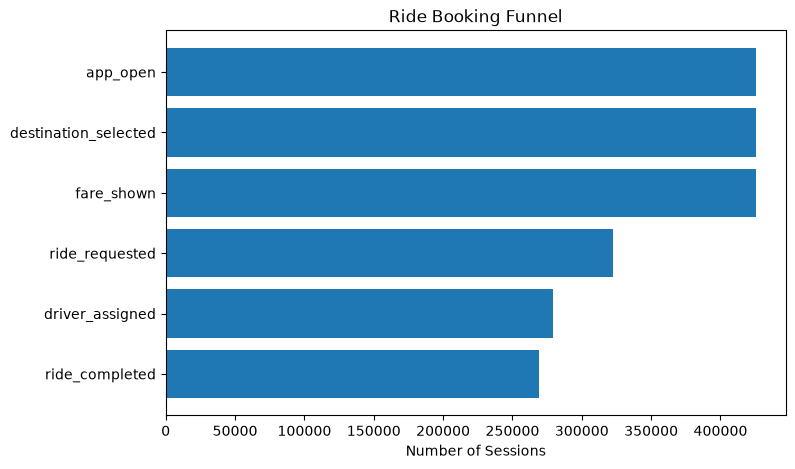

In [32]:
# Visualize Funnel
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    funnel_df["Funnel Stage"],
    funnel_df["Sessions"]
)

plt.gca().invert_yaxis()

plt.xlabel("Number of Sessions")
plt.title("Ride Booking Funnel")

plt.show()

### 3.2 Funnel Drop-off Analysis

In [33]:
dropoff_df = funnel_df.copy()

dropoff_df["Previous Stage"] = (
    dropoff_df["Sessions"].shift(1)
)

dropoff_df["Drop-off (%)"] = (
    (
        dropoff_df["Previous Stage"]
        - dropoff_df["Sessions"]
    )
    / dropoff_df["Previous Stage"]
    * 100
).round(2)

dropoff_df

,Funnel Stage,Sessions,Conversion Rate (%),Previous Stage,Drop-off (%)
0,app_open,425746,100.00,NaN,NaN
1,destination_selected,425746,100.00,425746.0,0.00
2,fare_shown,425746,100.00,425746.0,0.00
3,ride_requested,322582,75.77,425746.0,24.23
4,driver_assigned,279254,65.59,322582.0,13.43
5,ride_completed,269437,63.29,279254.0,3.52


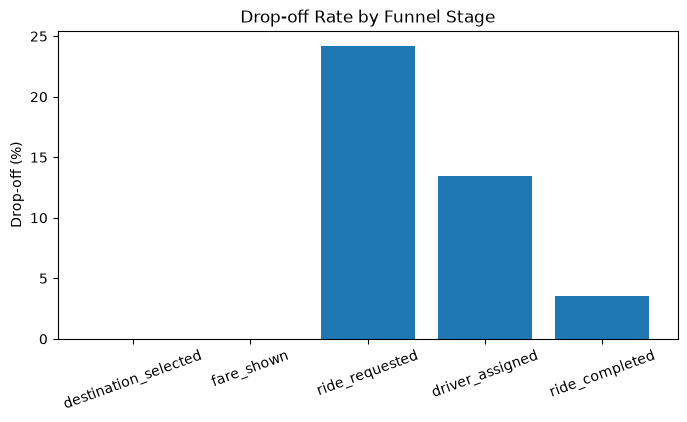

In [34]:
plt.figure(figsize=(8,4))

plt.bar(
    dropoff_df["Funnel Stage"][1:],
    dropoff_df["Drop-off (%)"][1:]
)

plt.ylabel("Drop-off (%)")
plt.title("Drop-off Rate by Funnel Stage")

plt.xticks(rotation=20)

plt.show()

### 3.3 Funnel Insights

Key findings from the funnel analysis include:

- Out of **425,746** booking sessions, **269,437** resulted in completed rides, yielding an overall ride completion rate of **63.29%**.
- The largest funnel drop-off occurred between **Fare Shown** and **Ride Requested**, where **24.23%** of users abandoned the booking before submitting a ride request. This represents the primary conversion bottleneck in the booking journey.
- A further **13.43%** of sessions dropped off before reaching **Driver Assigned**, indicating additional friction after users requested a ride.
- Once a driver was assigned, the booking process became relatively stable, with only **3.52%** of assigned rides failing to reach completion.
- Overall, the funnel suggests that the greatest opportunity to improve ride completion lies in reducing abandonment before driver assignment rather than after a driver has been matched.
- The following analyses investigate whether user segment, device type, city, ETA, surge pricing, and product experiments help explain these conversion patterns.

## 4. User Segment Analysis

Compare funnel performance across user segments.

### 4.1 Completion Rate by Segment

In [35]:
# Determine whether each session reached ride completion

completed_sessions = (
    events_df[events_df["event_name"] == "ride_completed"]
    [["session_id"]]
    .assign(completed=1)
)

segment_df = (
    sessions_df
    .merge(completed_sessions, on="session_id", how="left")
)

segment_df["completed"] = (
    segment_df["completed"]
    .fillna(0)
    .astype(int)
)

segment_summary = (
    segment_df
    .groupby("user_segment")
    .agg(
        Total_Sessions=("session_id", "count"),
        Completed_Rides=("completed", "sum")
    )
    .reset_index()
)

segment_summary["Completion Rate (%)"] = (
    segment_summary["Completed_Rides"]
    / segment_summary["Total_Sessions"]
    * 100
).round(2)

segment_summary = segment_summary.sort_values(
    "Completion Rate (%)",
    ascending=False
)

segment_summary

,user_segment,Total_Sessions,Completed_Rides,Completion Rate (%)
1,Power,204869,152998,74.68
2,Returning,181323,100662,55.52
0,New,39554,15777,39.89


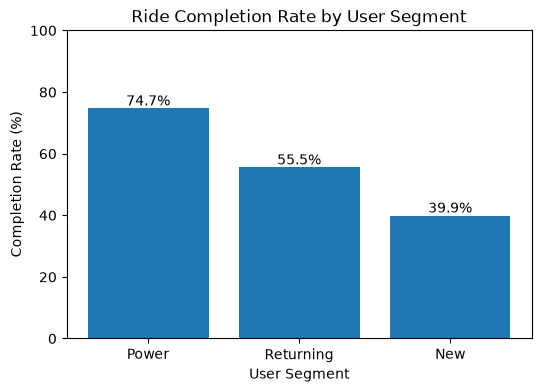

In [36]:
# Visualization
plt.figure(figsize=(6, 4))

bars = plt.bar(
    segment_summary["user_segment"],
    segment_summary["Completion Rate (%)"]
)

plt.title("Ride Completion Rate by User Segment")
plt.xlabel("User Segment")
plt.ylabel("Completion Rate (%)")
plt.ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center"
    )

plt.show()

### 4.2 Segment Insights

Key findings from the user segment analysis include:

- **Power** users achieved the highest ride completion rate at **74.68%**, indicating that experienced and highly engaged users are substantially more likely to complete the booking journey.
- **Returning** users recorded a completion rate of **55.52%**, suggesting moderate booking success but still exhibiting meaningful abandonment during the funnel.
- **New** users had the lowest completion rate at **39.89%**, meaning fewer than half of their booking sessions resulted in completed rides.
- The large performance gap between **New** and **Power** users suggests that familiarity with the platform may play an important role in booking completion.
- These findings indicate that onboarding improvements and early-user experience optimization may offer the greatest opportunity to increase overall ride completion.

## 5. Device and City Analysis

Analyze whether device type or city affects booking conversion.

### 5.1 Device Comparison

In [37]:
# Completion Rate by Device
device_summary = (
    segment_df
    .groupby("device_type")
    .agg(
        Total_Sessions=("session_id", "count"),
        Completed_Rides=("completed", "sum")
    )
    .reset_index()
)

device_summary["Completion Rate (%)"] = (
    device_summary["Completed_Rides"]
    / device_summary["Total_Sessions"]
    * 100
).round(2)

device_summary = device_summary.sort_values(
    "Completion Rate (%)",
    ascending=False
)

device_summary

,device_type,Total_Sessions,Completed_Rides,Completion Rate (%)
1,iOS,108118,68736,63.57
0,Android,317628,200701,63.19


### 5.2 City Comparison

In [38]:
# Completion Rate by Device
city_summary = (
    segment_df
    .groupby("city")
    .agg(
        Total_Sessions=("session_id","count"),
        Completed_Rides=("completed","sum")
    )
    .reset_index()
)

city_summary["Completion Rate (%)"] = (
    city_summary["Completed_Rides"]
    / city_summary["Total_Sessions"]
    *100
).round(2)

city_summary = city_summary.sort_values(
    "Completion Rate (%)",
    ascending=False
)

city_summary

,city,Total_Sessions,Completed_Rides,Completion Rate (%)
4,Yogyakarta,62880,41143,65.43
3,Surabaya,85621,55746,65.11
0,Bandung,86945,56061,64.48
2,Medan,43140,27384,63.48
1,Jakarta,147160,89103,60.55


### 5.3 Device & City Insights

Key findings from the device and city analysis include:

- Ride completion rates were nearly identical across device types, with **iOS** users achieving a completion rate of **63.57%** and **Android** users **63.19%**. This suggests that device type is unlikely to be a major driver of booking conversion.

- Greater variation was observed across cities. **Yogyakarta** recorded the highest completion rate (**65.43%**), followed closely by **Surabaya (65.11%)** and **Bandung (64.48%)**.

- **Jakarta** had the lowest completion rate at **60.55%**, indicating that users in the largest operating market were more likely to abandon the booking journey.

- The variation across cities suggests that local operational conditions, such as traffic congestion, driver availability, or dynamic pricing, may influence ride completion more than the mobile platform itself.

- These findings motivate further investigation into operational factors, particularly **ETA** and **surge pricing**, to better understand the lower conversion observed in certain cities.

## 6. ETA Impact Analysis

This section investigates whether longer pickup times are associated with lower ride completion rates.

### 6.1 ETA Distribution

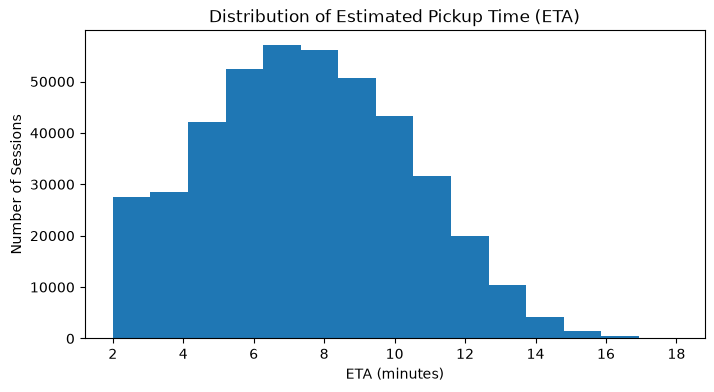

In [39]:
plt.figure(figsize=(8, 4))

plt.hist(
    sessions_df["eta_minutes"],
    bins=15
)

plt.title("Distribution of Estimated Pickup Time (ETA)")
plt.xlabel("ETA (minutes)")
plt.ylabel("Number of Sessions")

plt.show()

### 6.2 Completion Rate by ETA Bucket

In [40]:
eta_df = segment_df.copy()

eta_df["ETA Bucket"] = pd.cut(
    eta_df["eta_minutes"],
    bins=[0, 5, 10, 15, 20],
    labels=[
        "1–5",
        "6–10",
        "11–15",
        "16+"
    ]
)

eta_summary = (
    eta_df
    .groupby("ETA Bucket", observed=False)
    .agg(
        Total_Sessions=("session_id", "count"),
        Completed_Rides=("completed", "sum")
    )
    .reset_index()
)

eta_summary["Completion Rate (%)"] = (
    eta_summary["Completed_Rides"]
    / eta_summary["Total_Sessions"]
    * 100
).round(2)

eta_summary

,ETA Bucket,Total_Sessions,Completed_Rides,Completion Rate (%)
0,1–5,98072,64420,65.69
1,6–10,259573,165077,63.60
2,11–15,67627,39697,58.70
3,16+,474,243,51.27


### 6.3 ETA Insights

Key findings from the ETA analysis include:

- Most booking sessions had an estimated pickup time between **6 and 10 minutes**, indicating that relatively short waiting times are common across the platform.

- Ride completion rate consistently declined as estimated pickup time increased. Sessions with an ETA of **1–5 minutes** achieved the highest completion rate (**65.69%**), while sessions with an ETA of **16+ minutes** recorded the lowest completion rate (**51.27%**).

- The largest share of booking sessions fell within the **6–10 minute** range, where the completion rate remained relatively high (**63.60%**). However, completion declined noticeably once ETA exceeded **10 minutes**.

- These findings suggest that longer waiting times are associated with a greater likelihood of users abandoning the booking process before ride completion.

- The results support the hypothesis that pickup time is an important operational factor influencing ride completion and may partially explain the lower conversion observed across certain cities.

## 7. Surge Pricing Analysis

Perform hypothesis testing to evaluate experiment significance.

### 7.1 Surge Pricing Distribution

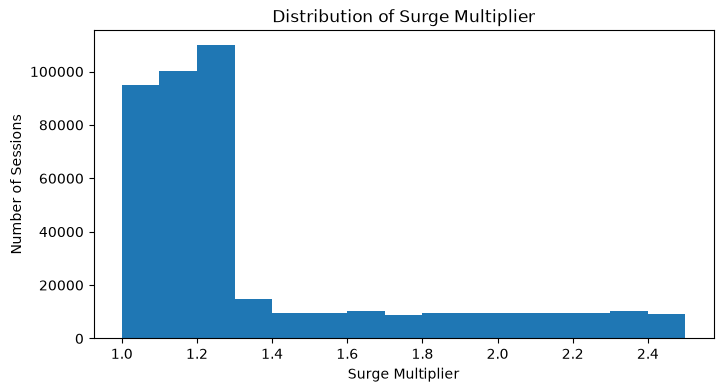

In [41]:
plt.figure(figsize=(8, 4))

plt.hist(
    sessions_df["surge_multiplier"],
    bins=15
)

plt.title("Distribution of Surge Multiplier")
plt.xlabel("Surge Multiplier")
plt.ylabel("Number of Sessions")

plt.show()

### 7.2 Completion Rate by Surge Bucket

In [43]:
surge_df = segment_df.copy()

surge_df["Surge Bucket"] = pd.cut(
    surge_df["surge_multiplier"],
    bins=[1.0, 1.2, 1.3, 1.4, 2.5],
    labels=[
        "1.0–1.2",
        "1.2–1.3",
        "1.3–1.4",
        "1.4+"
    ],
    include_lowest=True
)

surge_summary = (
    surge_df
    .groupby("Surge Bucket", observed=False)
    .agg(
        Total_Sessions=("session_id", "count"),
        Completed_Rides=("completed", "sum")
    )
    .reset_index()
)

surge_summary["Completion Rate (%)"] = (
    surge_summary["Completed_Rides"]
    / surge_summary["Total_Sessions"]
    * 100
).round(2)

surge_summary

,Surge Bucket,Total_Sessions,Completed_Rides,Completion Rate (%)
0,1.0–1.2,205692,138649,67.41
1,1.2–1.3,105408,71247,67.59
2,1.3–1.4,9622,6449,67.02
3,1.4+,105024,53092,50.55


### 7.3 Surge Pricing Insights

Key findings from the surge pricing analysis include:

- Ride completion remained relatively stable across surge multipliers below **1.4×**, with completion rates consistently around **67%**.

- Once the surge multiplier exceeded **1.4×**, ride completion dropped sharply from approximately **67%** to **50.55%**, representing the lowest completion rate among all pricing levels.

- The results suggest that moderate surge pricing has limited influence on booking behavior, whereas higher surge pricing may create significant pricing friction that discourages users from completing their bookings.

- Since a substantial number of booking sessions occurred under surge pricing above **1.4×**, optimizing the experience for these users could have a meaningful impact on overall ride completion.

- These findings provide a strong rationale for evaluating pricing interventions through A/B testing in the next section.

## 8. A/B Testing Evaluation

### 8.1 Experiment Overview

### 8.2 Statistical Testing

### 8.3 Experiment Insights

## 9. Conclusions & Recommendations